# Part 2 — Integration of Environmental Covariates


## 1. Imports & Configuration

In [1]:
import os
import re
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

DATA_DIR = r'C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Crop-Classification\Data'
COV_DIR  = os.path.join(DATA_DIR, 'covariates')
AR_PATH  = os.path.join(DATA_DIR, 'sentinel', 'arkansas.csv')
CA_PATH  = os.path.join(DATA_DIR, 'sentinel', 'california.csv')
SAVE_DIR = DATA_DIR

COV_FILES = {
    'AR': [
        os.path.join(COV_DIR, 'MCTNet_Arkansas_Zone1_covariates.csv'),
        os.path.join(COV_DIR, 'MCTNet_Arkansas_Zone2_covariates.csv'),
    ],
    'CA': [
        os.path.join(COV_DIR, 'MCTNet_California_Zone1_covariates.csv'),
        os.path.join(COV_DIR, 'MCTNet_California_Zone2_covariates.csv'),
    ],
}

N_TIMESTEPS = 36
N_BANDS     = 10
BAND_ORDER  = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
META_COLS   = ['label', 'crop_name', 'lat', 'lon',
               'latitude', 'longitude', 'system:index', '.geo', 'crop_id']
DOY         = [(i + 1) * 10 for i in range(N_TIMESTEPS)]

CLIM_COLS = ['precipitation', 'temperature', 'solar_radiation']
SOIL_COLS = ['soil_pH', 'organic_carbon', 'soil_texture']
TOPO_COLS = ['elevation', 'landforms']
ALL_COVS  = CLIM_COLS + SOIL_COLS + TOPO_COLS

RENAME_MAP = {
    'precip_annual_mm'  : 'precipitation',
    'precipitation'     : 'precipitation',
    'temp_mean_degC'    : 'temperature',
    'temperature'       : 'temperature',
    'solar_mean_Wm2'    : 'solar_radiation',
    'solar_radiation'   : 'solar_radiation',
    'soil_pH_0cm'       : 'soil_pH',
    'soil_pH'           : 'soil_pH',
    'soil_OC_gkg'       : 'organic_carbon',
    'organic_carbon'    : 'organic_carbon',
    'soil_texture_class': 'soil_texture',
    'soil_texture'      : 'soil_texture',
    'elevation_m'       : 'elevation',
    'elevation'         : 'elevation',
    'landforms_class'   : 'landforms',
    'landforms'         : 'landforms',
}

CONFIGS = {
    'D0 — Sentinel only'    : [],
    'D1 — Sentinel + Climate': ['precipitation', 'temperature', 'solar_radiation'],
    'D2 — Sentinel + Soil'   : ['soil_pH', 'organic_carbon', 'soil_texture'],
    'D3 — Sentinel + Topo'   : ['elevation', 'landforms'],
    'D4 — Sentinel + All'    : ['precipitation', 'temperature', 'solar_radiation',
                                'soil_pH', 'organic_carbon', 'soil_texture',
                                'elevation', 'landforms'],
}

N_HEADS     = 5
KERNEL_SIZE = 3
DROPOUT     = 0.1
LR          = 0.001
N_EPOCHS    = 200
BATCH_SIZE  = 32
WEIGHT_DECAY = 1e-4
PATIENCE    = 10

PART1_AR = {'OA': 0.952, 'Kappa': 0.927, 'F1': 0.863}
PART1_CA = {'OA': 0.901, 'Kappa': 0.853, 'F1': 0.646}

Device  : cpu
PyTorch : 2.11.0+cpu


## 2. Data Loading

In [2]:
def extract_latlon(df):
    if 'lat' in df.columns and 'lon' in df.columns:
        return df['lat'].values, df['lon'].values
    elif 'latitude' in df.columns and 'longitude' in df.columns:
        return df['latitude'].values, df['longitude'].values
    elif '.geo' in df.columns:
        coords = df['.geo'].apply(lambda x: json.loads(x)['coordinates'])
        lons   = coords.apply(lambda c: c[0]).values
        lats   = coords.apply(lambda c: c[1]).values
        return lats, lons
    else:
        raise ValueError('No lat/lon columns found in dataframe.')


def load_covariates(file_list):
    frames = [pd.read_csv(f) for f in file_list]
    df_cov = pd.concat(frames, ignore_index=True)
    df_cov = df_cov.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df_cov.columns})
    lats, lons = extract_latlon(df_cov)
    df_cov['_lat'] = lats
    df_cov['_lon'] = lons
    return df_cov


df_ar = pd.read_csv(AR_PATH)
df_ca = pd.read_csv(CA_PATH)

cov_ar = load_covariates(COV_FILES['AR'])
cov_ca = load_covariates(COV_FILES['CA'])

print('Sentinel Arkansas   :', df_ar.shape)
print('Sentinel California :', df_ca.shape)
print('Covariates Arkansas :', cov_ar.shape)
print('Covariates California:', cov_ca.shape)

available_ar = [c for c in ALL_COVS if c in cov_ar.columns]
available_ca = [c for c in ALL_COVS if c in cov_ca.columns]
print('\nCovariate columns found (AR):', available_ar)
print('Covariate columns found (CA):', available_ca)

Sentinel Arkansas   : (10000, 364)
Sentinel California : (10000, 364)
Covariates Arkansas : (30905, 13)
Covariates California: (17057, 13)

Covariate columns found (AR): ['precipitation', 'temperature', 'solar_radiation', 'soil_pH', 'organic_carbon', 'soil_texture', 'elevation', 'landforms']
Covariate columns found (CA): ['precipitation', 'temperature', 'solar_radiation', 'soil_pH', 'organic_carbon', 'soil_texture', 'elevation', 'landforms']


## 3. Covariate Exploration

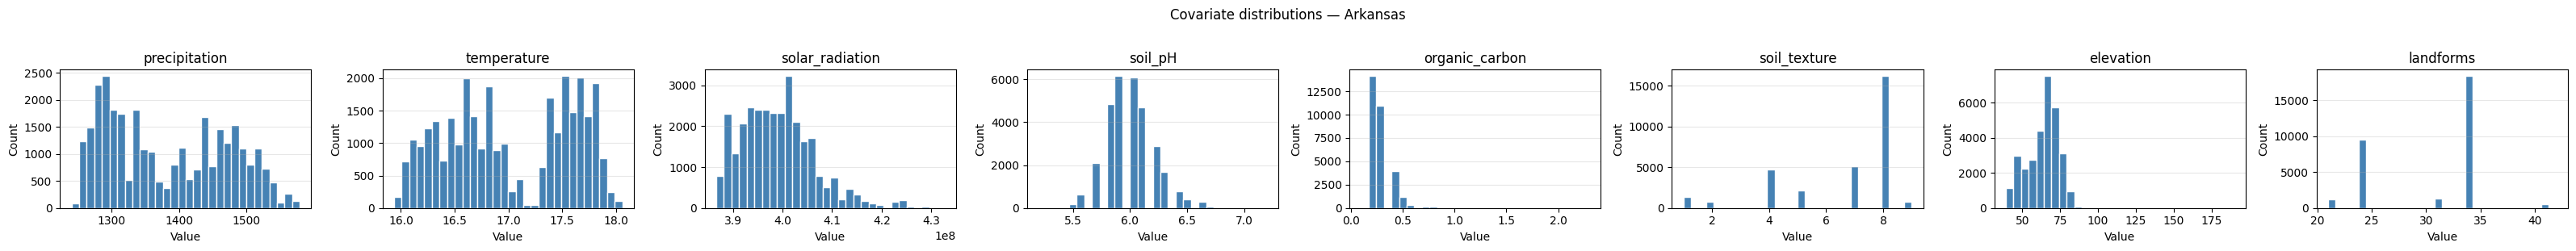

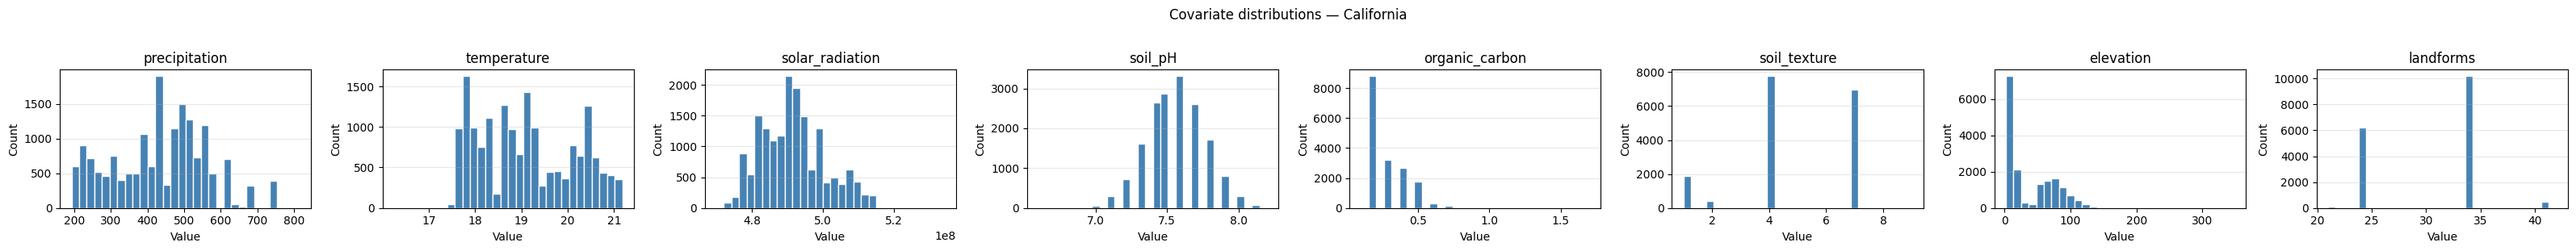

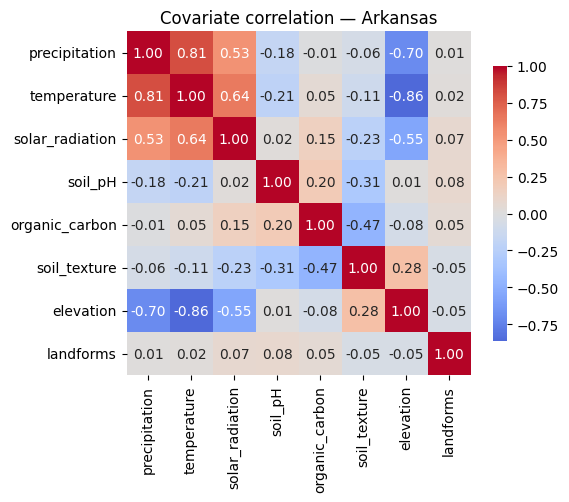

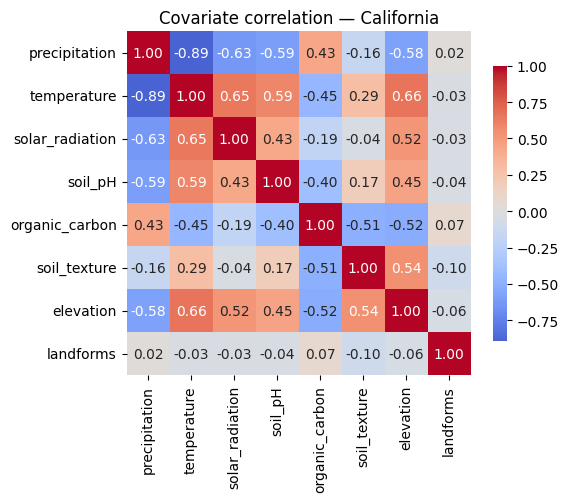

In [3]:
for cov_df, region in [(cov_ar, 'Arkansas'), (cov_ca, 'California')]:
    available = [c for c in ALL_COVS if c in cov_df.columns]
    if not available:
        print(f'{region}: no covariate columns found after renaming.')
        continue

    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, available):
        data = cov_df[col].dropna()
        ax.hist(data, bins=30, color='steelblue', edgecolor='white')
        ax.set_title(col)
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        ax.grid(alpha=0.3, axis='y')

    fig.suptitle(f'Covariate distributions — {region}', y=1.02)
    plt.tight_layout()
    plt.show()


for cov_df, region in [(cov_ar, 'Arkansas'), (cov_ca, 'California')]:
    available = [c for c in ALL_COVS if c in cov_df.columns]
    if len(available) < 2:
        continue

    corr = cov_df[available].corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, cbar_kws={'shrink': 0.8})
    plt.title(f'Covariate correlation — {region}')
    plt.tight_layout()
    plt.show()

## 4. GPS Alignment



In [4]:
def align_covariates(df_sentinel, df_cov, cov_cols):
    sent_lats, sent_lons = extract_latlon(df_sentinel)

    cov_coords = np.deg2rad(
        np.column_stack([df_cov['_lat'].values, df_cov['_lon'].values])
    )
    tree = BallTree(cov_coords, metric='haversine')

    sent_coords = np.deg2rad(np.column_stack([sent_lats, sent_lons]))
    _, indices  = tree.query(sent_coords, k=1)
    indices     = indices.flatten()

    available = [c for c in cov_cols if c in df_cov.columns]
    C = df_cov.iloc[indices][available].values.astype(np.float32)
    return C, available


C_ar_full, avail_ar = align_covariates(df_ar, cov_ar, ALL_COVS)
C_ca_full, avail_ca = align_covariates(df_ca, cov_ca, ALL_COVS)

print(f'Aligned covariates Arkansas   : {C_ar_full.shape}  columns: {avail_ar}')
print(f'Aligned covariates California : {C_ca_full.shape}  columns: {avail_ca}')

Aligned covariates Arkansas   : (10000, 8)  columns: ['precipitation', 'temperature', 'solar_radiation', 'soil_pH', 'organic_carbon', 'soil_texture', 'elevation', 'landforms']
Aligned covariates California : (10000, 8)  columns: ['precipitation', 'temperature', 'solar_radiation', 'soil_pH', 'organic_carbon', 'soil_texture', 'elevation', 'landforms']


## 5. Preprocessing



In [5]:
def get_feature_cols(df):
    return [c for c in df.columns if c not in META_COLS]


def sort_feature_columns(feat_cols):
    def sort_key(col):
        m     = re.search(r'_t(\d+)$', col)
        t_idx = int(m.group(1)) if m else 0
        band  = re.sub(r'_t\d+$', '', col)
        b_idx = BAND_ORDER.index(band) if band in BAND_ORDER else 99
        return (t_idx, b_idx)
    return sorted(feat_cols, key=sort_key)


def preprocess(df, C_full, seed=42,
               n_train_default=240, n_val_default=60,
               n_train_small=120,   n_val_small=30,
               small_threshold=300, min_test=30):
    rng = np.random.RandomState(seed)

    feat_cols = sort_feature_columns(get_feature_cols(df))
    X_raw = df[feat_cols].values.reshape(-1, N_TIMESTEPS, N_BANDS).astype(np.float32)
    mask  = (~np.isnan(X_raw).any(axis=2)).astype(np.float32)
    X_raw = np.nan_to_num(X_raw, nan=0.0)

    le = LabelEncoder()
    y  = le.fit_transform(df['crop_name'].values)

    train_idx, val_idx, test_idx = [], [], []

    print(f'\n  {"Class":<20} {"Total":>6} {"Train":>6} {"Val":>5} {"Test":>6}  Protocol')
    print('  ' + '-' * 60)

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        n = len(cls_idx)

        if n >= small_threshold and (n - n_train_default - n_val_default) >= min_test:
            nt, nv = n_train_default, n_val_default
            protocol = 'paper (240/60)'
        else:
            nt = min(n_train_small, int(n * 0.6))
            nv = min(n_val_small,   int(n * 0.2))
            protocol = f'small  ({nt}/{nv})'

        if nt + nv > n - min_test:
            nv = max(1, int(n * 0.15))
            nt = max(1, n - nv - min_test)

        train_idx.extend(cls_idx[:nt])
        val_idx.extend(cls_idx[nt:nt + nv])
        test_idx.extend(cls_idx[nt + nv:])

        cls_name = le.classes_[cls]
        print(f'  {cls_name:<20} {n:>6} {nt:>6} {nv:>5} {n - nt - nv:>6}  {protocol}')

    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    X_tr, mask_tr, y_tr = X_raw[train_idx], mask[train_idx], y[train_idx]
    X_va, mask_va, y_va = X_raw[val_idx],   mask[val_idx],   y[val_idx]
    X_te, mask_te, y_te = X_raw[test_idx],  mask[test_idx],  y[test_idx]

    norm_mean = X_tr.mean(axis=(0, 1), keepdims=True)
    norm_std  = X_tr.std(axis=(0, 1),  keepdims=True) + 1e-8
    X_tr = (X_tr - norm_mean) / norm_std
    X_va = (X_va - norm_mean) / norm_std
    X_te = (X_te - norm_mean) / norm_std

    C_tr = C_full[train_idx].astype(np.float32)
    C_va = C_full[val_idx].astype(np.float32)
    C_te = C_full[test_idx].astype(np.float32)

    cov_mean = C_tr.mean(axis=0, keepdims=True)
    cov_std  = C_tr.std(axis=0,  keepdims=True) + 1e-8
    C_tr = (C_tr - cov_mean) / cov_std
    C_va = (C_va - cov_mean) / cov_std
    C_te = (C_te - cov_mean) / cov_std

    print(f'\n  Train : {len(y_tr):>5} samples ({len(np.unique(y_tr))} classes)')
    print(f'  Val   : {len(y_va):>5} samples')
    print(f'  Test  : {len(y_te):>5} samples')

    return {
        'X_train': X_tr, 'mask_train': mask_tr, 'C_train': C_tr, 'y_train': y_tr,
        'X_val':   X_va, 'mask_val':   mask_va, 'C_val':   C_va, 'y_val':   y_va,
        'X_test':  X_te, 'mask_test':  mask_te, 'C_test':  C_te, 'y_test':  y_te,
        'norm_mean': norm_mean, 'norm_std': norm_std,
        'cov_mean': cov_mean,   'cov_std':  cov_std,  'le': le,
    }


print('--- Arkansas ---')
data_ar = preprocess(df_ar, C_ar_full)

print('\n--- California ---')
data_ca = preprocess(df_ca, C_ca_full)

--- Arkansas ---

  Class                 Total  Train   Val   Test  Protocol
  ------------------------------------------------------------
  Corn                   1320    240    60   1020  paper (240/60)
  Cotton                 1052    240    60    752  paper (240/60)
  Others                  430    240    60    130  paper (240/60)
  Rice                   2430    240    60   2130  paper (240/60)
  Soybeans               4768    240    60   4468  paper (240/60)

  Train :  1200 samples (5 classes)
  Val   :   300 samples
  Test  :  8500 samples

--- California ---

  Class                 Total  Train   Val   Test  Protocol
  ------------------------------------------------------------
  Alfalfa                 301    120    30    151  small  (120/30)
  Almonds                 585    240    60    285  paper (240/60)
  Grapes                 3471    240    60   3171  paper (240/60)
  Others                 3842    240    60   3542  paper (240/60)
  Pistachios              454    24

## 6. Dataset & DataLoaders

In [6]:
class CropDatasetFused(Dataset):
    def __init__(self, X, mask, C, y):
        if C.shape[1] > 0:
            C_rep   = np.repeat(C[:, np.newaxis, :], X.shape[1], axis=1)
            X_fused = np.concatenate([X, C_rep], axis=2)
        else:
            X_fused = X
        self.X    = torch.FloatTensor(X_fused)
        self.mask = torch.FloatTensor(mask)
        self.y    = torch.LongTensor(y)
 
    def __len__(self):
        return len(self.y)
 
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]
 
 
def make_loaders(data, cov_cols, avail_cols, batch_size=32):
    avail_list = list(avail_cols)
 
    if len(cov_cols) == 0:
        C_tr = np.zeros((len(data['y_train']), 0), dtype=np.float32)
        C_va = np.zeros((len(data['y_val']),   0), dtype=np.float32)
        C_te = np.zeros((len(data['y_test']),  0), dtype=np.float32)
        input_dim = N_BANDS
    else:
        col_idx   = [avail_list.index(c) for c in cov_cols if c in avail_list]
        C_tr = data['C_train'][:, col_idx]
        C_va = data['C_val'][:,   col_idx]
        C_te = data['C_test'][:,  col_idx]
        input_dim = N_BANDS + len(col_idx)
 
    train_ds = CropDatasetFused(data['X_train'], data['mask_train'], C_tr, data['y_train'])
    val_ds   = CropDatasetFused(data['X_val'],   data['mask_val'],   C_va, data['y_val'])
    test_ds  = CropDatasetFused(data['X_test'],  data['mask_test'],  C_te, data['y_test'])
 
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False),
        input_dim,
    )
 
 
print('DataLoader builder ready.')

DataLoader builder ready.


## 7. Model Architecture — MCTNet 


In [7]:
class ALPE(nn.Module):
    def __init__(self, n_times=36, n_bands=10):
        super().__init__()

        pe = torch.zeros(n_times, n_bands)
        for t in range(n_times):
            for i in range(0, n_bands, 2):
                pe[t, i]     = math.sin(t / (10000 ** (2 * i / n_bands)))
                if i + 1 < n_bands:
                    pe[t, i+1] = math.cos(t / (10000 ** (2 * i / n_bands)))
        self.register_buffer('pe', pe.unsqueeze(0))

        self.conv = nn.Conv1d(n_bands, n_bands, kernel_size=3, padding=1)

        self.eca_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x, mask):
        pe_masked = self.pe * mask.unsqueeze(-1)

        pe_t = pe_masked.permute(0, 2, 1)
        pe_t = self.conv(pe_t)

        attn = self.eca_pool(pe_t)
        attn = attn.permute(0, 2, 1)
        attn = self.eca_conv(attn)
        attn = self.sigmoid(attn).permute(0, 2, 1)
        pe_out = (pe_t * attn).permute(0, 2, 1)

        return x + pe_out


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(d_model)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(d_model)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop(x)
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)


class CTFusion(nn.Module):
    def __init__(self, in_ch, out_ch, n_heads, kernel_size=3,
                 dropout=0.1, use_alpe=False, n_times=36):
        super().__init__()
        self.use_alpe = use_alpe
        half = out_ch // 2

        if use_alpe:
            self.alpe = ALPE(n_times=n_times, n_bands=in_ch)

        self.proj = nn.Linear(in_ch, out_ch)

        self.cnn = CNNSubModule(half, kernel_size, dropout)

        self.transformer = TransformerSubModule(half, n_heads, dropout)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)

        x = self.proj(x)
        half = x.shape[-1] // 2
        x_cnn  = x[..., :half]
        x_tran = x[..., half:]

        x_cnn = self.cnn(x_cnn.permute(0, 2, 1)).permute(0, 2, 1)

        x_tran = self.transformer(x_tran)

        x = torch.cat([x_cnn, x_tran], dim=-1)

        x = self.pool(x.permute(0, 2, 1)).permute(0, 2, 1)

        return x


class MCTNet(nn.Module):
    def __init__(self, n_bands, n_classes, n_heads=5, kernel_size=3,
                 dropout=0.1, n_times=36):
        super().__init__()
        self.stage1 = CTFusion(n_bands, 20, n_heads=n_heads,
                               kernel_size=kernel_size, dropout=dropout,
                               use_alpe=True, n_times=n_times)
        self.stage2 = CTFusion(20, 40, n_heads=n_heads,
                               kernel_size=kernel_size, dropout=dropout)
        self.stage3 = CTFusion(40, 80, n_heads=n_heads,
                               kernel_size=kernel_size, dropout=dropout)
        self.classifier = nn.Linear(80, n_classes)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.stage1(x, mask)
        x = self.stage2(x)
        x = self.stage3(x)
        x = x.max(dim=1).values
        x = self.drop(x)
        return self.classifier(x)


n_classes_ar = len(data_ar['le'].classes_)
n_classes_ca = len(data_ca['le'].classes_)

model_ar = MCTNet(N_BANDS, n_classes_ar, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
model_ca = MCTNet(N_BANDS, n_classes_ca, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)

x_dummy    = torch.randn(4, N_TIMESTEPS, N_BANDS).to(device)
mask_dummy = torch.ones(4, N_TIMESTEPS).to(device)
out = model_ar(x_dummy, mask_dummy)
print(f'MCTNet output shape : {out.shape}  (expected: [4, {n_classes_ar}])')

n_params = sum(p.numel() for p in model_ar.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

MCTNet output shape : torch.Size([4, 5])  (expected: [4, 5])
Trainable parameters: 35,648


## 8. Training & Ablation Study


In [8]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    criterion  = nn.CrossEntropyLoss()
 
    for X_b, mask_b, y_b in loader:
        X_b, mask_b = X_b.to(device), mask_b.to(device)
        logits = model(X_b, mask_b)
        total_loss += criterion(logits, y_b.to(device)).item()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_b.numpy())
 
    oa    = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return oa, kappa, f1, total_loss / len(loader), all_preds, all_labels


def train(model, data_loaders, region, n_epochs=N_EPOCHS, patience=PATIENCE):
    train_loader, val_loader, _ = data_loaders[:3]
 
    y_train = data_loaders[0].dataset.y.numpy()
    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(class_weights).to(device)
    )
 
    optimizer = optim.Adam(model.parameters(), lr=LR)
 
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0
    history       = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_f1': []}
 
    print(f'Training MCTNet — {region}')
    print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<12} {"Val OA":<10} {"Val F1"}')
    print('-' * 55)
 
    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
 
        for X_b, mask_b, y_b in train_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b, mask_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
 
        train_loss /= len(train_loader)
        val_oa, _, val_f1, val_loss, _, _ = evaluate(model, val_loader)
 
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_oa'].append(val_oa)
        history['val_f1'].append(val_f1)
 
        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:<8} {train_loss:<14.4f} {val_loss:<12.4f} {val_oa:<10.4f} {val_f1:.4f}')
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'\nEarly stopping at epoch {epoch}')
                break
 
    model.load_state_dict(best_state)
    print(f'Done. Best val loss: {best_val_loss:.4f}')
    return history

In [9]:
def make_loaders_direct(data, batch_size=32):
    """Build DataLoaders directly from a preprocessed data dict."""
    train_ds = CropDatasetFused(
        data['X_train'], data['mask_train'], data['C_train'], data['y_train']
    )
    val_ds = CropDatasetFused(
        data['X_val'], data['mask_val'], data['C_val'], data['y_val']
    )
    test_ds = CropDatasetFused(
        data['X_test'], data['mask_test'], data['C_test'], data['y_test']
    )
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False),
        data['C_train'].shape[1],
    )

In [10]:
ablation_results = {}

for config_name, cov_cols in CONFIGS.items():
    print(f'\n{"=" * 60}')
    print(f'Config : {config_name}')
    print(f'{"=" * 60}')

    ablation_results[config_name] = {}

    for data, avail_cols, region in [
        (data_ar, avail_ar, 'Arkansas'),
        (data_ca, avail_ca, 'California'),
    ]:
        loaders_tuple = make_loaders(data, cov_cols, list(avail_cols), BATCH_SIZE)
        train_loader, val_loader, test_loader, input_dim = loaders_tuple

        n_classes = len(data['le'].classes_)
        model = MCTNet(input_dim, n_classes, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)

        print(f'\n  {region} — input_dim={input_dim}')
        history = train(model, (train_loader, val_loader, test_loader), region)

        oa, kappa, f1, _, preds, labels = evaluate(model, test_loader)
        ablation_results[config_name][region] = {
            'OA'       : oa,
            'Kappa'    : kappa,
            'F1'       : f1,
            'input_dim': input_dim,
            'preds'    : preds,
            'labels'   : labels,
        }
        print(f'  Test — OA={oa:.3f}  Kappa={kappa:.3f}  F1={f1:.3f}')

print(f'\n{"Configuration":<30} {"Region":<12} {"OA":>7} {"Kappa":>7} {"F1":>7}')
print('=' * 67)
for cfg, regions in ablation_results.items():
    for region, metrics in regions.items():
        print(f'{cfg:<30} {region:<12} {metrics["OA"]:>7.3f} {metrics["Kappa"]:>7.3f} {metrics["F1"]:>7.3f}')


Config : D0 — Sentinel only

  Arkansas — input_dim=10
Training MCTNet — Arkansas
Epoch    Train Loss     Val Loss     Val OA     Val F1
-------------------------------------------------------
1        1.4431         1.1809       0.6400     0.6275
10       0.1921         0.2707       0.8800     0.8793
20       0.0939         0.4945       0.8700     0.8691

Early stopping at epoch 25
Done. Best val loss: 0.1940
  Test — OA=0.946  Kappa=0.918  F1=0.855

  California — input_dim=10
Training MCTNet — California
Epoch    Train Loss     Val Loss     Val OA     Val F1
-------------------------------------------------------
1        1.2976         0.8840       0.6939     0.6775
10       0.2563         0.4236       0.8788     0.8864
20       0.1262         0.4897       0.8818     0.8904

Early stopping at epoch 25
Done. Best val loss: 0.4093
  Test — OA=0.906  Kappa=0.862  F1=0.804

Config : D1 — Sentinel + Climate

  Arkansas — input_dim=13
Training MCTNet — Arkansas
Epoch    Train Loss     V

## 9. Results & Comparison


Arkansas
Configuration                   OA    Kappa       F1
----------------------------------------------------
Part 1 (baseline)            0.952    0.927    0.863
D0 — Sentinel only           0.946    0.918    0.855
D1 — Sentinel + Climate      0.933    0.899    0.840
D2 — Sentinel + Soil         0.904    0.857    0.805
D3 — Sentinel + Topo         0.937    0.904    0.845
D4 — Sentinel + All          0.939    0.907    0.851

California
Configuration                   OA    Kappa       F1
----------------------------------------------------
Part 1 (baseline)            0.901    0.853    0.646
D0 — Sentinel only           0.906    0.862    0.804
D1 — Sentinel + Climate      0.913    0.871    0.815
D2 — Sentinel + Soil         0.897    0.850    0.798
D3 — Sentinel + Topo         0.894    0.845    0.779
D4 — Sentinel + All          0.899    0.851    0.761


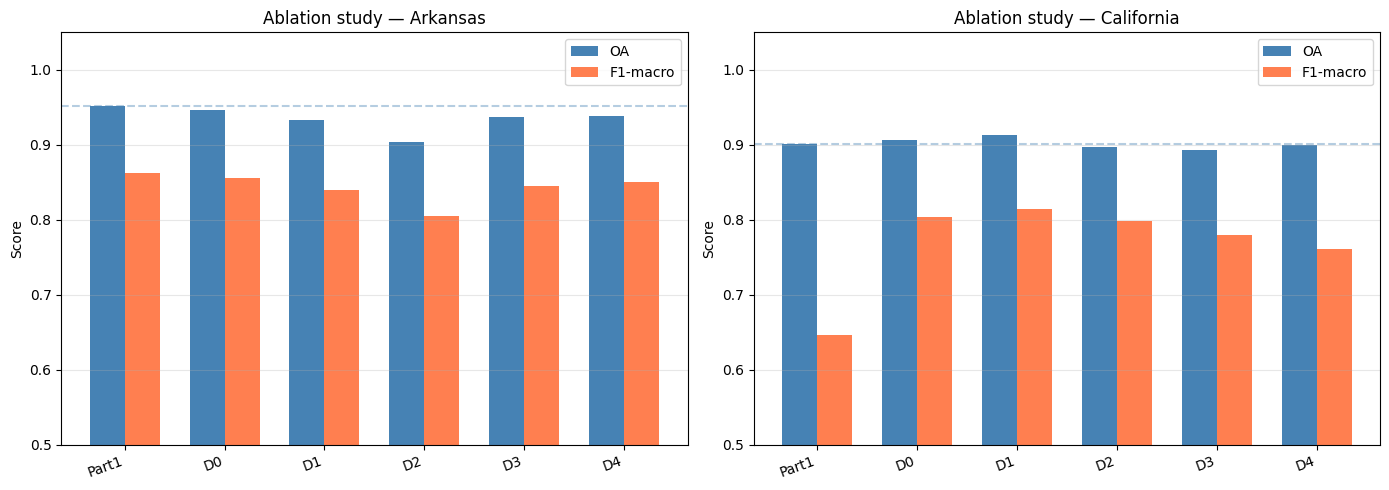

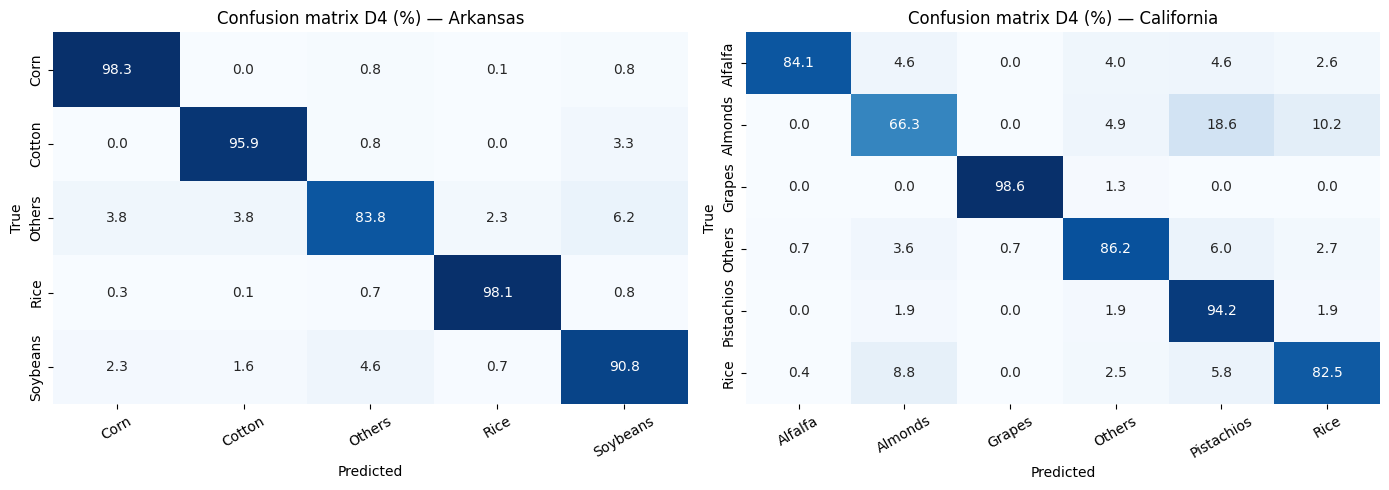

In [11]:
for region, part1 in [('Arkansas', PART1_AR), ('California', PART1_CA)]:
    print(f'\n{region}')
    print(f'{"Configuration":<25} {"OA":>8} {"Kappa":>8} {"F1":>8}')
    print('-' * 52)
    print(f'{"Part 1 (baseline)":<25} {part1["OA"]:>8.3f} {part1["Kappa"]:>8.3f} {part1["F1"]:>8.3f}')

    for config_name, res in ablation_results.items():
        r = res[region]
        print(f'{config_name:<25} {r["OA"]:>8.3f} {r["Kappa"]:>8.3f} {r["F1"]:>8.3f}')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, region, part1 in [
    (axes[0], 'Arkansas',   PART1_AR),
    (axes[1], 'California', PART1_CA),
]:
    configs = ['Part 1'] + list(ablation_results.keys())

    oa_vals = [part1['OA']] + [
        ablation_results[c][region]['OA'] for c in ablation_results
    ]

    f1_vals = [part1['F1']] + [
        ablation_results[c][region]['F1'] for c in ablation_results
    ]

    x = np.arange(len(configs))
    w = 0.35

    b1 = ax.bar(x - w/2, oa_vals, w, label='OA',      color='steelblue')
    b2 = ax.bar(x + w/2, f1_vals, w, label='F1-macro', color='coral')

    ax.set_title(f'Ablation study — {region}')
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Part1', 'D0', 'D1', 'D2', 'D3', 'D4'],
        rotation=20,
        ha='right'
    )
    ax.set_ylabel('Score')
    ax.set_ylim(0.5, 1.05)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(part1['OA'], color='steelblue', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


D4_KEY = 'D4 — Sentinel + All'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (region, data) in zip(axes, [
    ('Arkansas',   data_ar),
    ('California', data_ca),
]):
    res    = ablation_results[D4_KEY][region]
    labels = res['labels']
    preds  = res['preds']

    cm     = confusion_matrix(labels, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct,
        annot=True, fmt='.1f', cmap='Blues',
        xticklabels=data['le'].classes_,
        yticklabels=data['le'].classes_,
        ax=ax, cbar=False
    )
    ax.set_title(f'Confusion matrix D4 (%) — {region}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 10. Save Best Model (D4)

In [15]:
D4_KEY = 'D4 — Sentinel + All'

for region, region_key in [('Arkansas', 'AR'), ('California', 'CA')]:
    path = os.path.join(SAVE_DIR, f'ablation_results_D4_{region_key}.pth')
    torch.save({
        'ablation_results' : ablation_results[D4_KEY][region],
        'all_configs'      : {
            cfg: ablation_results[cfg][region]
            for cfg in ablation_results
        },
        'cov_cols'         : CONFIGS[D4_KEY],
    }, path)
    print(f'Saved: {path}')

Saved: C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Last-version\Data\ablation_results_D4_AR.pth
Saved: C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Last-version\Data\ablation_results_D4_CA.pth
